In [ ]:
import os
import sys

import pandas as pd
from copy import deepcopy

In [2]:
path_this = os.path.dirname(os.path.abspath(__name__))
path_root= os.path.join(path_this, '..')
path_dataset = os.path.join(path_root, 'data')

In [5]:
def preprocess_churn_col(value:str):
	if isinstance(value, int):
		return value
	elif value.lower() == 'yes':
		return 1
	elif value.lower() == 'no':
		return 0

In [6]:
df_dataset = pd.read_csv(os.path.join(path_dataset,'dataset.csv'))
df_dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df_dataset['TotalCharges'] = pd.to_numeric(df_dataset['TotalCharges'], errors='coerce')
df_dataset['Churn'] = df_dataset['Churn'].map(preprocess_churn_col)
df_dataset = df_dataset.loc[df_dataset['tenure'] != 0].reset_index(drop=True)
df_dataset.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [9]:
df_xgboost = deepcopy(df_dataset)

In [77]:
df_xgboost.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [80]:
TARGET = 'Churn'
X = df_xgboost.drop(columns=[
	TARGET, 'customerID', 'gender', 'SeniorCitizen', 
	'Partner', 'Dependents', 'TotalCharges', 'PaperlessBilling',
	'PaymentMethod'])
y = df_xgboost[TARGET]
y.value_counts(dropna=False, normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [81]:
X.columns

Index(['tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'MonthlyCharges'],
      dtype='object')

In [82]:
numerical_features = X.select_dtypes(exclude='object').columns.to_list()
categorical_features = X.select_dtypes(include='object').columns.to_list()

In [83]:
preprocessor = ColumnTransformer([
	('num', 'passthrough', numerical_features),
	('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
])

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, stratify=y, random_state=42)

In [85]:
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

In [86]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train_enc, label=y_train)
dtest  = xgb.DMatrix(X_test_enc, label=y_test)


In [87]:
params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 4,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": (y_train.value_counts()[0] / y_train.value_counts()[1]),
    "seed": 42
}


In [88]:
evals = [(dtrain, "train"), (dtest, "valid")]

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=500,
    evals=evals,
    early_stopping_rounds=30,
    verbose_eval=False
)


In [89]:
y_prob = model.predict(dtest)
y_pred = (y_prob >= 0.5).astype(int)


In [90]:
from sklearn.metrics import classification_report, log_loss, roc_auc_score

print(classification_report(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_prob))
print("ROC AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407

Log Loss: 0.5031626293966314
ROC AUC: 0.8340680019257549


# Cross Validation

In [44]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
import numpy as np
import xgboost as xgb

cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=X)
    dval   = xgb.DMatrix(X_val, label=y_val)

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=500,
        evals=[(dval, "val")],
        early_stopping_rounds=30,
        verbose_eval=False
    )

    cv_scores.append(model.best_score)


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:PhoneService: object, MultipleLines: object, InternetService: object, OnlineSecurity: object, OnlineBackup: object, DeviceProtection: object, TechSupport: object, StreamingTV: object, StreamingMovies: object, Contract: object, PaperlessBilling: object, PaymentMethod: object

In [48]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
	break

In [50]:
train_idx, val_idx

(array([   0,    1,    3, ..., 7028, 7029, 7030], shape=(5625,)),
 array([   2,   10,   18, ..., 7020, 7027, 7031], shape=(1407,)))

In [53]:
X.shape

(7032, 14)

---

# REVISI CODING

In [91]:
numerical_features = X.select_dtypes(exclude='object').columns.to_list()
categorical_features = X.select_dtypes(include='object').columns.to_list()

In [92]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [93]:
xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}


In [94]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score, f1_score,
    log_loss
)

In [171]:
cv_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
	print(f'\n--- Fold {fold} ---')

	# split (IMPORTANT: iloc)
	X_tr = X.iloc[train_idx]
	X_val = X.iloc[val_idx]
	y_tr = y.iloc[train_idx]
	y_val = y.iloc[val_idx]

	# preprocessing (fit ONLY on train)
	preprocessor = ColumnTransformer(
		transformers=[
			('num', 'passthrough', numerical_features),
			('cat', OneHotEncoder(handle_unknown='ignore',drop='first'), categorical_features)
		]
	)

	X_tr_enc = preprocessor.fit_transform(X_tr)
	X_val_enc = preprocessor.transform(X_val)

	# DMatrix
	dtrain = xgb.DMatrix(X_tr_enc, label=y_tr)
	dval = xgb.DMatrix(X_val_enc, label=y_val)

	# train
	model = xgb.train(
		params=xgb_params,
		dtrain=dtrain,
		num_boost_round=500,
		evals=[(dval, 'validation')],
		early_stopping_rounds=30,
		verbose_eval=False
	)

	# prediction
	y_val_proba = model.predict(dval)
	thresholds = np.linspace(0.1, 0.5, 50)
	
	# find better threshold
	best_f1 = 0
	best_t = 0

	for t in thresholds:
		y_pred_t = (y_val_proba >= t).astype(int)
		f1 = f1_score(y_val, y_pred_t)

		if f1 > best_f1:
			best_f1 = f1
			best_t = t

	best_f1
	# get better threshold
	y_val_pred = (y_val_proba >= best_t).astype(int)

	# metrics
	fold_metrics = {
		'fold': fold,
		'logloss': log_loss(y_val, y_val_proba),
		'accuracy': accuracy_score(y_val, y_val_pred),
		'precision': precision_score(y_val, y_val_pred),
		'recall': recall_score(y_val, y_val_pred),
		'f1-score': f1_score(y_val, y_val_pred),
		'roc_auc': roc_auc_score(y_val, y_val_proba),
		'best_iteration': model.best_iteration,
		'best_t': best_t,
		'best_f1': best_f1
	}

	cv_results.append(fold_metrics)



--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---


In [172]:
cv_df = pd.DataFrame(cv_results)

print("\n===== CV PERFORMANCE =====")
print(cv_df.mean(numeric_only=True))
print("\nStd Dev:")
print(cv_df.std(numeric_only=True))



===== CV PERFORMANCE =====
fold                3.000000
logloss             0.415007
accuracy            0.773750
precision           0.558304
recall              0.748557
f1-score            0.637539
roc_auc             0.845869
best_iteration    105.400000
best_t              0.322041
best_f1             0.637539
dtype: float64

Std Dev:
fold               1.581139
logloss            0.004878
accuracy           0.016623
precision          0.033011
recall             0.052021
f1-score           0.006646
roc_auc            0.004281
best_iteration    15.533834
best_t             0.047739
best_f1            0.006646
dtype: float64


In [173]:
cv_df

,fold,logloss,accuracy,precision,recall,f1-score,roc_auc,best_iteration,best_t,best_f1
0,1,0.416323,0.770434,0.551102,0.735294,0.630011,0.844982,86,0.328571,0.630011
1,2,0.409153,0.768301,0.545113,0.775401,0.640177,0.850782,116,0.287755,0.640177
2,3,0.419378,0.753201,0.522727,0.801609,0.632804,0.841979,109,0.287755,0.632804
3,4,0.410615,0.778094,0.560784,0.764706,0.647059,0.849876,93,0.304082,0.647059
4,5,0.419566,0.798720,0.611794,0.665775,0.637644,0.841725,123,0.402041,0.637644


In [174]:
importance = model.get_score(importance_type="gain")

feature_names = preprocessor.get_feature_names_out()
feature_names


array(['num__tenure', 'num__MonthlyCharges', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes',
       'cat__InternetService_Fiber optic', 'cat__InternetService_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No internet service',
       'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No internet service', 'cat__StreamingTV_Yes',
       'cat__StreamingMovies_No internet service',
       'cat__StreamingMovies_Yes', 'cat__Contract_One year',
       'cat__Contract_Two year'], dtype=object)

In [160]:
# len(importance.values())
len(feature_names)

21

In [175]:
importance_df = pd.DataFrame({
	'feature': feature_names,
	'gain': [
		importance.get(f"f{i}", 0.0)
		for i in range(len(feature_names))
	]
})
print(importance_df.shape)
importance_df.sort_values(by='gain', ascending=False)

(21, 2)


,feature,gain
20,cat__Contract_Two year,62.594448
5,cat__InternetService_Fiber optic,35.228851
19,cat__Contract_One year,27.948364
7,cat__OnlineSecurity_No internet service,22.014854
6,cat__InternetService_No,20.780544
0,num__tenure,10.465621
14,cat__TechSupport_Yes,9.064425
3,cat__MultipleLines_No phone service,6.304290
8,cat__OnlineSecurity_Yes,5.932227
2,cat__PhoneService_Yes,5.247078


In [162]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='gain', ylabel='feature'>

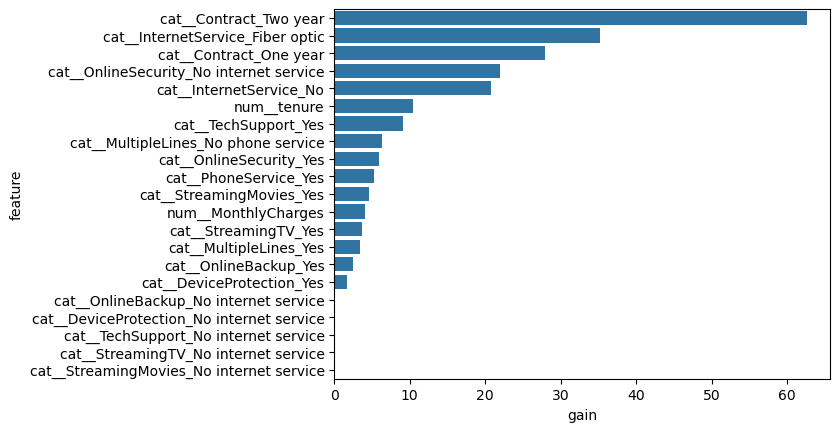

In [163]:
sns.barplot(importance_df.sort_values(by='gain', ascending=False), x='gain', y='feature')

In [164]:
import shap
import matplotlib.pyplot as plt


In [185]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_tr_enc)
shap_values


array([[ 1.2604121 , -0.22741133,  0.24386996, ..., -0.06792434,
         0.20841329,  0.33261162],
       [-0.51030254, -0.11361801, -0.04467252, ..., -0.12423626,
        -0.68668354,  0.21456985],
       [ 0.83675843, -0.1061303 , -0.04257904, ..., -0.05094687,
         0.17777066,  0.30196452],
       ...,
       [ 0.01780184, -0.18068495,  0.16207649, ..., -0.06584053,
         0.18492591,  0.28308037],
       [ 0.6283294 , -0.11026818, -0.02225286, ..., -0.05730453,
         0.21655512,  0.33146888],
       [-0.56929344,  0.6638608 , -0.01002233, ...,  0.0464758 ,
         0.05995174, -1.6223356 ]], shape=(5626, 21), dtype=float32)

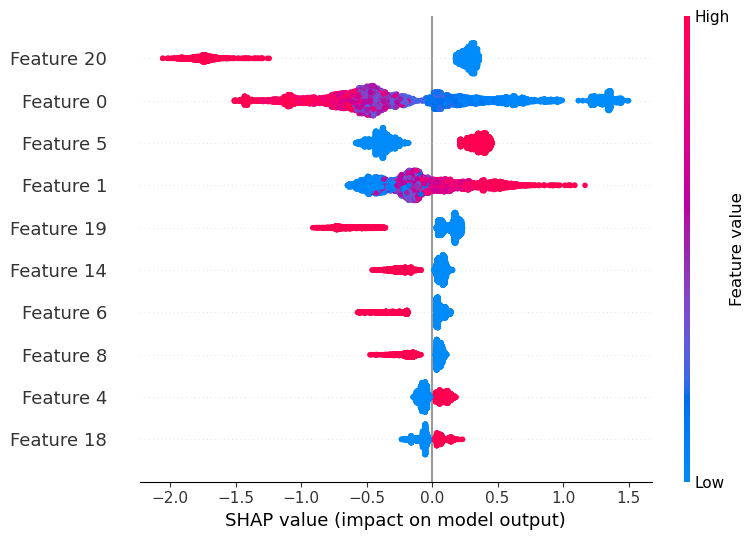

In [186]:
shap.summary_plot(
    shap_values,
    X_tr_enc,
    plot_type="dot",
    max_display=10
)


In [181]:
# shap_values = explainer.shap_values(X_train)
model.feature_names = X_train.columns.to_list()

In [187]:
model.feature_names 

['tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'MonthlyCharges']